In [48]:
from sqlalchemy import create_engine
import pandas as pd
import os
from sshtunnel import SSHTunnelForwarder
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import re

from sshtunnel import SSHTunnelForwarder
import socket
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [49]:
plt.rcParams['font.family'] = 'Century Gothic'

In [50]:


SSH_HOST = "3.139.164.72"
SSH_PORT = 22
SSH_USER = "dclaudiopacheco"
SSH_KEY_PATH = r"I:\Mi unidad\credenciales\dclaudiopacheco.pem"
SSH_KEY_PASSPHRASE = "+THB2JaMpy5/Ma0V7yiQn*MfHMuSw9EsEL3kgR56"

REMOTE_DB_HOST = "agdatabases.cu1njaiwfxac.us-east-2.rds.amazonaws.com"
REMOTE_DB_PORT = 3306

tunnel = SSHTunnelForwarder(
    (SSH_HOST, SSH_PORT),
    ssh_username=SSH_USER,
    ssh_pkey=SSH_KEY_PATH,
    ssh_private_key_password=SSH_KEY_PASSPHRASE,
    remote_bind_address=(REMOTE_DB_HOST, REMOTE_DB_PORT),
    local_bind_address=("127.0.0.1", 33007)
)

tunnel.start()

print("Puerto local:", tunnel.local_bind_port)

# Ahora probamos si realmente responde el puerto
sock = socket.socket()
result = sock.connect_ex(("127.0.0.1", tunnel.local_bind_port))

if result == 0:
    print("✅ El túnel sí conecta al RDS")
else:
    print("❌ El túnel NO conecta al RDS")

sock.close()

Puerto local: 33007
✅ El túnel sí conecta al RDS


In [51]:
from sqlalchemy import create_engine, text

DB_USER = "dclaudiopacheco"
DB_PASS = "BgDR5BA7UUj7zIJuLUSr3SzKRkT28N1r1nLeEqsV"
DB_NAME = "ciencia_datos"

DATABASE_URL = (
    f"mysql+pymysql://{DB_USER}:{DB_PASS}"
    f"@127.0.0.1:{tunnel.local_bind_port}/{DB_NAME}"
)

engine = create_engine(DATABASE_URL)

with engine.connect() as conn:
    print("✅ MySQL responde:", conn.execute(text("SELECT 1")).scalar())

✅ MySQL responde: 1


In [52]:
import pandas as pd
import time


def ejecutar_sps(engine, sps_dict, verbose=True):
    """
    Ejecuta múltiples stored procedures y devuelve los resultados en un diccionario de DataFrames.
    
    Parámetros
    ----------
    engine : sqlalchemy.engine
        Conexión a la base de datos.
        
    sps_dict : dict
        Diccionario con estructura:
        {
            "nombre_resultado": ("schema.sp_name", [param1, param2, ...]),
        }
        
    verbose : bool
        Si True imprime información de ejecución.
        
    Returns
    -------
    dict
        Diccionario con DataFrames resultantes.
    """
    
    resultados = {}
    
    for nombre, (sp, params) in sps_dict.items():
        
        try:
            
            start = time.time()
            
            # Construir parámetros
            if params:
                params_sql = ", ".join(str(p) for p in params)
            else:
                params_sql = ""
            
            query = f"CALL {sp}({params_sql})"
            
            if verbose:
                print(f"\nEjecutando: {query}")
            
            df = pd.read_sql(query, engine)
            
            elapsed = round(time.time() - start, 2)
            
            if verbose:
                print(f"{nombre}: {len(df)} registros | {elapsed}s")
            
            resultados[nombre] = df
            
        except Exception as e:
            
            print(f"Error ejecutando {sp}: {e}")
            resultados[nombre] = None
            
    return resultados



def barplot_ordenado(data, x, y, etiqueta_formato=None, color="#0033A0"):
    
    # Ordenar por variable del eje x
    data = data.sort_values(x, ascending=False)
    
    ax = sns.barplot(
        data=data,
        x=x,
        y=y,
        color=color
    )
    
    # Agregar etiquetas
    for i, v in enumerate(data[x]):
        
        if etiqueta_formato:
            texto = etiqueta_formato(v)
        else:
            texto = f"{v}"
        
        ax.text(
            v,
            i,
            f"{v:.1f}%",
            va="center",
            ha="left",
            fontsize=10
        )
    
    return ax

In [53]:
stored_procedures = {
    "abandono": ("ciencia_datos.sp_tasa_abandono", ["NULL"]),
    "abandono_programa": ("ciencia_datos.sp_tasa_abandono", [3]),
    "abandono_empresa": ("ciencia_datos.sp_tasa_abandono", [2]),
    "retencion": ("ciencia_datos.sp_tasa_retencion", []),
    "fragilidad": ("ciencia_datos.sp_tasa_fragilidad_inicial_abandono_temprano", ["NULL"]),
    "fragilidad_programa": ("ciencia_datos.sp_tasa_fragilidad_inicial_abandono_temprano", [3]),
    "bajas_sn_cargas": ("ciencia_datos.sp_bajas_alumnos_sn_cargas", [])
}

resultados = ejecutar_sps(engine, stored_procedures)


Ejecutando: CALL ciencia_datos.sp_tasa_abandono(NULL)
abandono: 24315 registros | 5.76s

Ejecutando: CALL ciencia_datos.sp_tasa_abandono(3)
abandono_programa: 24315 registros | 5.4s

Ejecutando: CALL ciencia_datos.sp_tasa_abandono(2)
abandono_empresa: 24315 registros | 5.57s

Ejecutando: CALL ciencia_datos.sp_tasa_retencion()
retencion: 1801 registros | 0.53s

Ejecutando: CALL ciencia_datos.sp_tasa_fragilidad_inicial_abandono_temprano(NULL)
fragilidad: 7551 registros | 9.93s

Ejecutando: CALL ciencia_datos.sp_tasa_fragilidad_inicial_abandono_temprano(3)
fragilidad_programa: 7551 registros | 10.25s

Ejecutando: CALL ciencia_datos.sp_bajas_alumnos_sn_cargas()
bajas_sn_cargas: 13581 registros | 15.79s


In [54]:
# Tablas
abandono = resultados["abandono"]
abandono_programa = resultados["abandono_programa"]
abandono_empresa = resultados["abandono_empresa"]
retencion = resultados["retencion"]
fragilidad = resultados["fragilidad"]
fragilidad_programa = resultados["fragilidad_programa"]
bajas_sn_cargas = resultados["bajas_sn_cargas"]

In [55]:
retencion

,anio,fecha_registro,categoria,id_plan_estudio,programa,id_corporacion,corporacion,id_alumno,id_moodle,estatus_casa,motivo,intervencion,retencion,id_motivo_interno,motivo_interno
0,2025,2025-01-29,Ingeniería,18,IDS Coppel,2,COPPEL,2828,28934,BAJA DEL PROGRAMA,Retención,0,Sin intervención,1,No se ha tenido contacto con el/la estudiante
1,2025,2025-01-29,Ingeniería,18,IDS Coppel,2,COPPEL,2900,28924,BAJA DEL PROGRAMA,Retención,0,Sin intervención,1,No se ha tenido contacto con el/la estudiante
2,2025,2025-09-15,Preparatoria,85,Prepa alpura,14,ALPURA,89319,687,SUSPENDIDOS POR INACTIVIDAD,Retención,0,Sin intervención,1,No se ha tenido contacto con el/la estudiante
3,2025,2025-02-12,Preparatoria,85,Prepa alpura,14,ALPURA,89334,718,BAJA DEL PROGRAMA,Retención,1,NO,2,Compatibilidad del programa / expectativas
4,2025,2025-06-25,Preparatoria,49,PREPA AG COLLEGE,1,AG COLLEGE,89429,743,ACTIVO,Retención,1,NO,6,Económicos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1796,2026,2026-02-17,Licenciatura,62,LEG COPPEL,2,COPPEL,200703,57649,None,Retención,0,Pendiente,1,No se ha tenido contacto con el/la estudiante
1797,2026,2026-02-16,Preparatoria,47,PREPA COPPEL,2,COPPEL,200763,57824,None,Retención,0,Pendiente,1,No se ha tenido contacto con el/la estudiante
1798,2026,2026-02-19,Licenciatura,62,LEG COPPEL,2,COPPEL,200824,57751,None,Retención,0,Pendiente,1,No se ha tenido contacto con el/la estudiante
1799,2026,2026-02-17,Licenciatura,62,LEG COPPEL,2,COPPEL,200863,57956,None,Retención,0,Pendiente,1,No se ha tenido contacto con el/la estudiante


#### Intervención

In [56]:
##Calcular tasa de abandono por año
intervencion_gral = (
    retencion
    .groupby("anio")
    .agg(
        total_registros=("id_alumno", "count"),
        total_bajas=("intervencion", "sum")
    )
    .reset_index()
)

# Calcular tasa de abandono
intervencion_gral["tasa_intervencion"] = (
    intervencion_gral["total_bajas"] / intervencion_gral["total_registros"]*100
)

intervencion_gral

,anio,total_registros,total_bajas,tasa_intervencion
0,2024,42,31,73.809524
1,2025,1566,970,61.941252
2,2026,193,99,51.295337


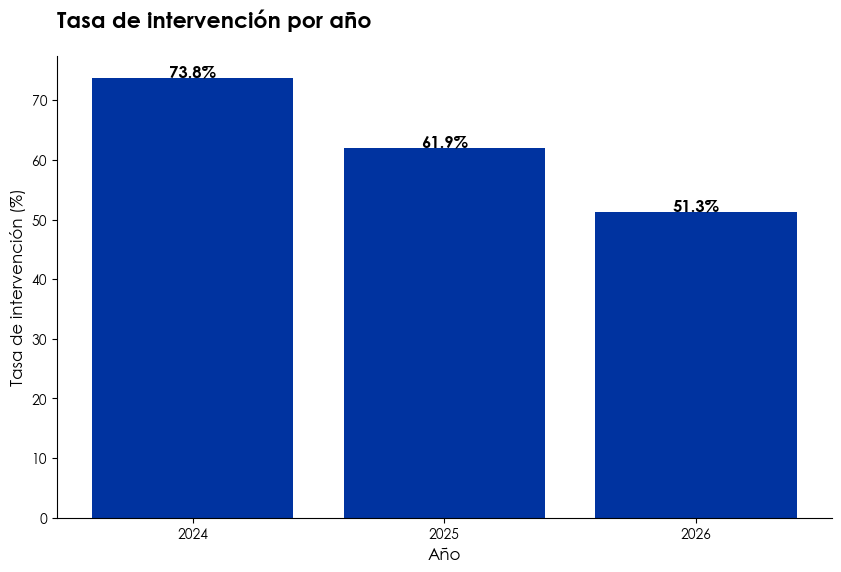

In [57]:
# Grafico de barras
plt.figure(figsize=(10, 6))
plt.bar(intervencion_gral["anio"], intervencion_gral["tasa_intervencion"], color="#0033A0")
plt.title("Tasa de intervención por año", fontsize=16, pad=20, color="black", fontweight="bold", loc="left")
plt.xlabel("Año", fontsize=12)
plt.ylabel("Tasa de intervención (%)", fontsize=12)
#Añadir etiquetas de porcentaje encima de cada barra
for index, row in intervencion_gral.iterrows():
    plt.text(row["anio"], row["tasa_intervencion"] + 0.2,
              f"{row['tasa_intervencion']:.1f}%", ha='center', fontsize=12, color="black", fontweight="bold")

plt.xticks(intervencion_gral["anio"])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

In [58]:
# Intervención por corporación
interv_corp = (
    retencion
    .groupby(["anio", "corporacion"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_interv=("intervencion", "sum")
    )
    .reset_index()
)
interv_corp["tasa_intervencion"] = (
    interv_corp["total_interv"] / interv_corp["total_registros"]*
    100
)
interv_corp

,anio,corporacion,total_registros,total_interv,tasa_intervencion
0,2024,AG COLLEGE,2,2,100.000000
1,2024,ALPURA,1,1,100.000000
2,2024,CASA LEY,1,0,0.000000
3,2024,COPPEL,38,28,73.684211
4,2025,AG COLLEGE,134,79,58.955224
5,2025,AG SOCIAL,2,1,50.000000
6,2025,ALPURA,39,24,61.538462
7,2025,BAYER,9,7,77.777778
8,2025,CASA LEY,85,60,70.588235
9,2025,COPPEL,1217,754,61.955629


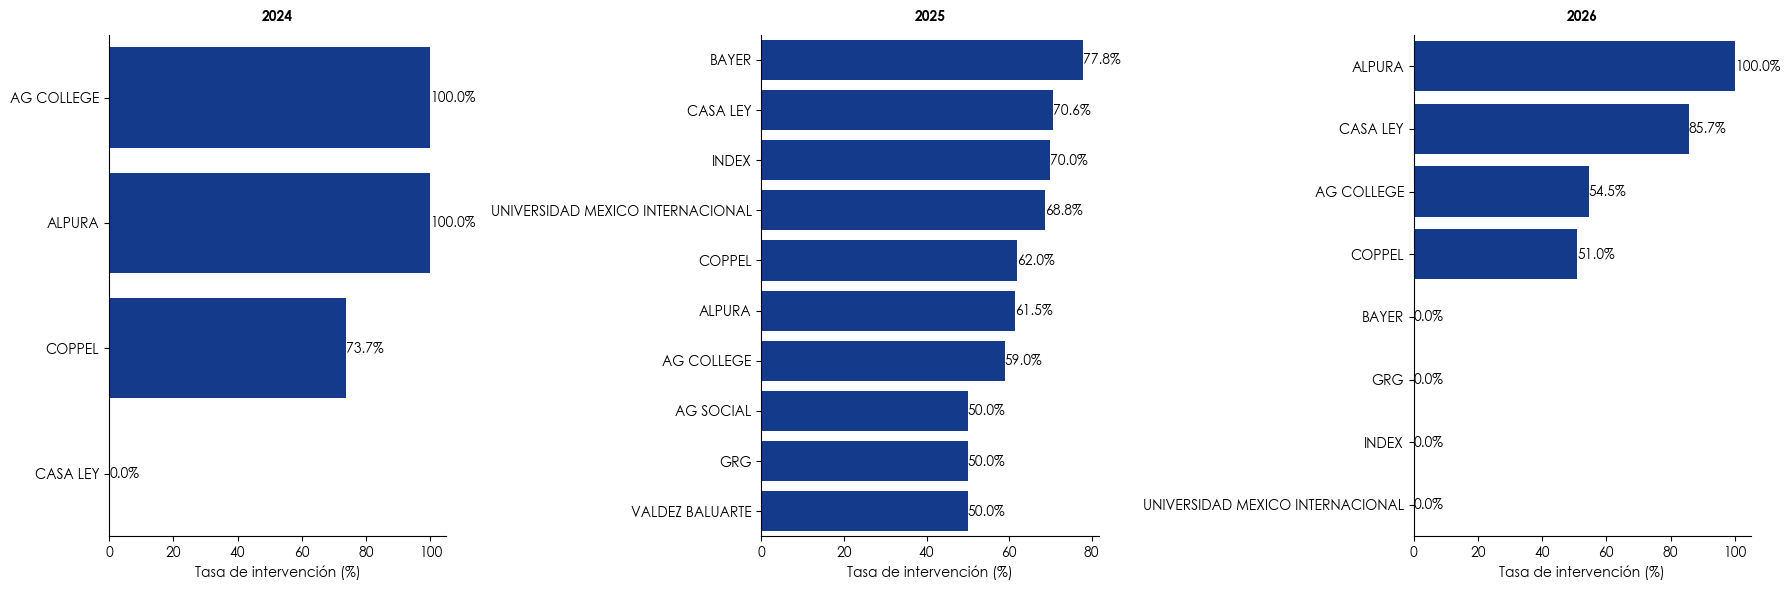

In [59]:
# Copia y ordena dentro de cada año
df_plot = interv_corp.copy()
# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_intervencion", y="corporacion", color="#0033A0")

# Títulos y estilo
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de intervención (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [60]:
#Intervención por programa
interv_prog = (
    retencion
    .groupby(["anio", "programa"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_interv=("intervencion", "sum")
    )
    .reset_index()
)
interv_prog["tasa_interv"] = (
    interv_prog["total_interv"] / interv_prog["total_registros"]*
    100
)
interv_prog

,anio,programa,total_registros,total_interv,tasa_interv
0,2024,IDS Coppel,10,5,50.000000
1,2024,LDG AG LIC,2,2,100.000000
2,2024,LDG Ley,1,0,0.000000
3,2024,LEG COPPEL,18,14,77.777778
4,2024,MDN Coppel,4,4,100.000000
5,2024,PREPA COPPEL,6,5,83.333333
6,2024,Prepa alpura,1,1,100.000000
7,2025,ADMISIONES IDS COPPEL,1,0,0.000000
8,2025,BACHILLERATO FALCO ELECTRONICS,1,0,0.000000
9,2025,BACHILLERATO INDEX,6,4,66.666667


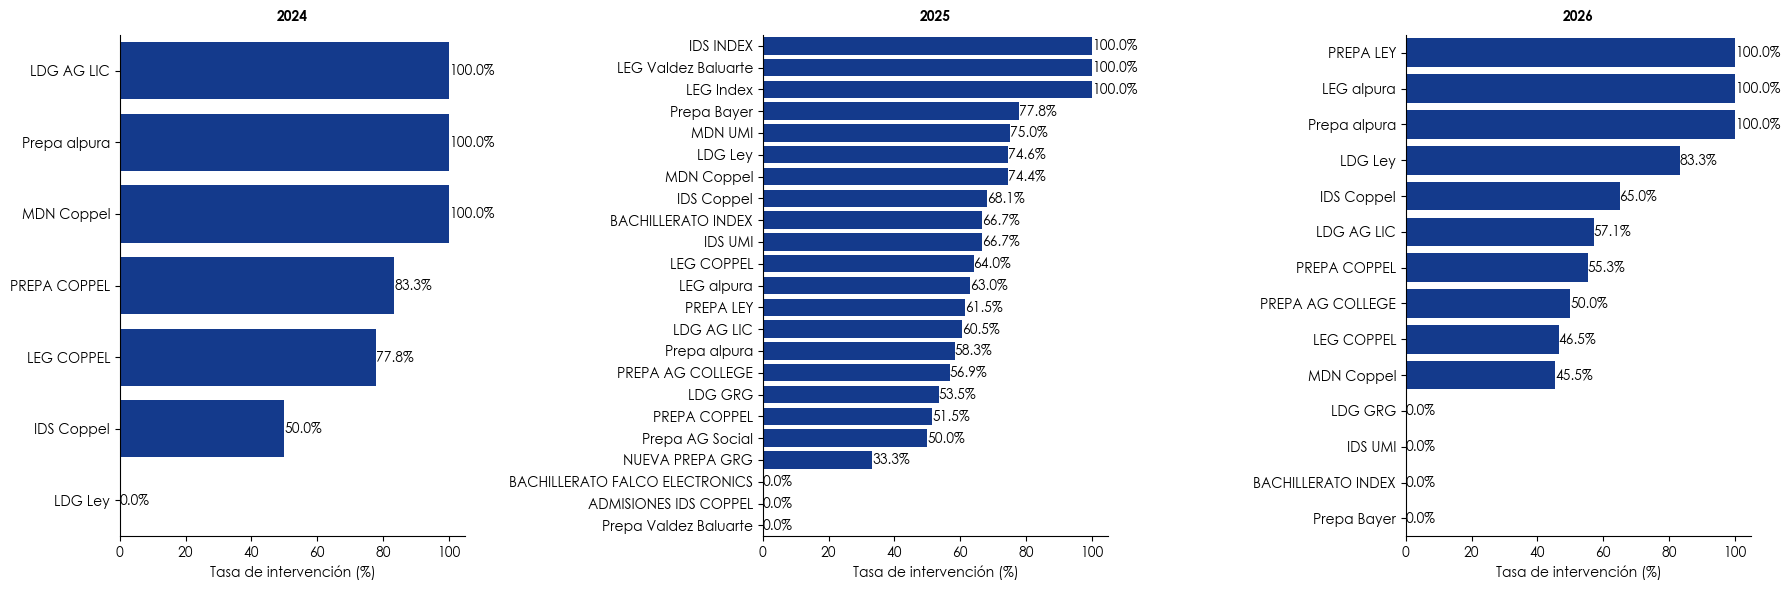

In [61]:
# Copia y ordena dentro de cada año
df_plot = interv_prog.copy()
# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_interv", y="programa", color="#0033A0")

# Títulos y estilo
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de intervención (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Retención

In [62]:
retencion_gral = (
    retencion
    .groupby("anio")
    .agg(
        total_intervenidos=("intervencion", "sum"),
        total_retencion=("retencion", lambda x: (x == "SI").sum())
    )
    .reset_index()
)

retencion_gral["tasa_retencion"] = (
    retencion_gral["total_retencion"] /
    retencion_gral["total_intervenidos"] * 100
).round(2)

retencion_gral

,anio,total_intervenidos,total_retencion,tasa_retencion
0,2024,31,9,29.03
1,2025,970,256,26.39
2,2026,99,24,24.24


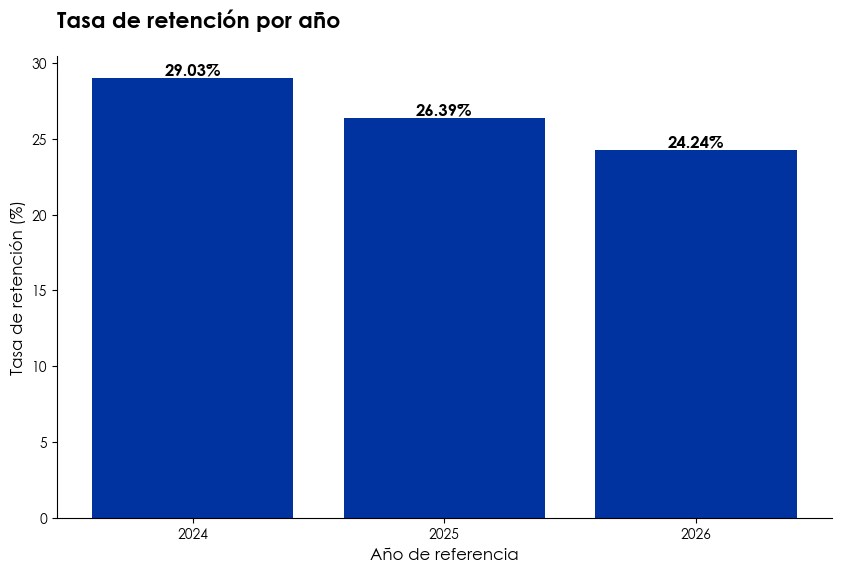

In [63]:
# Grafico de barras
plt.figure(figsize=(10, 6))
plt.bar(retencion_gral["anio"], retencion_gral["tasa_retencion"], color="#0033A0")
plt.title("Tasa de retención por año", fontsize=16, pad=20, color="black", fontweight="bold", loc="left")
plt.xlabel("Año de referencia", fontsize=12)
plt.ylabel("Tasa de retención (%)", fontsize=12)
#Añadir etiquetas de porcentaje encima de cada barra
for index, row in retencion_gral.iterrows():
    plt.text(row["anio"], row["tasa_retencion"] + 0.2,
              f"{row['tasa_retencion']:.2f}%", ha='center', fontsize=12, color="black", fontweight="bold")

plt.xticks(retencion_gral["anio"])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

In [64]:
##Retención por corporación

retencion_corp = (
    retencion
    .groupby(["anio", "corporacion"])
    .agg(
        total_intervenidos=("intervencion", "sum"),
        total_retencion=("retencion", lambda x: (x == "SI").sum())
    )
    .reset_index()
)
retencion_corp["tasa_retencion"] = (
    retencion_corp["total_retencion"] /
    retencion_corp["total_intervenidos"] * 100
).round(2)
retencion_corp


,anio,corporacion,total_intervenidos,total_retencion,tasa_retencion
0,2024,AG COLLEGE,2,0,0.00
1,2024,ALPURA,1,1,100.00
2,2024,CASA LEY,0,0,NaN
3,2024,COPPEL,28,8,28.57
4,2025,AG COLLEGE,79,23,29.11
5,2025,AG SOCIAL,1,1,100.00
6,2025,ALPURA,24,8,33.33
7,2025,BAYER,7,0,0.00
8,2025,CASA LEY,60,21,35.00
9,2025,COPPEL,754,193,25.60


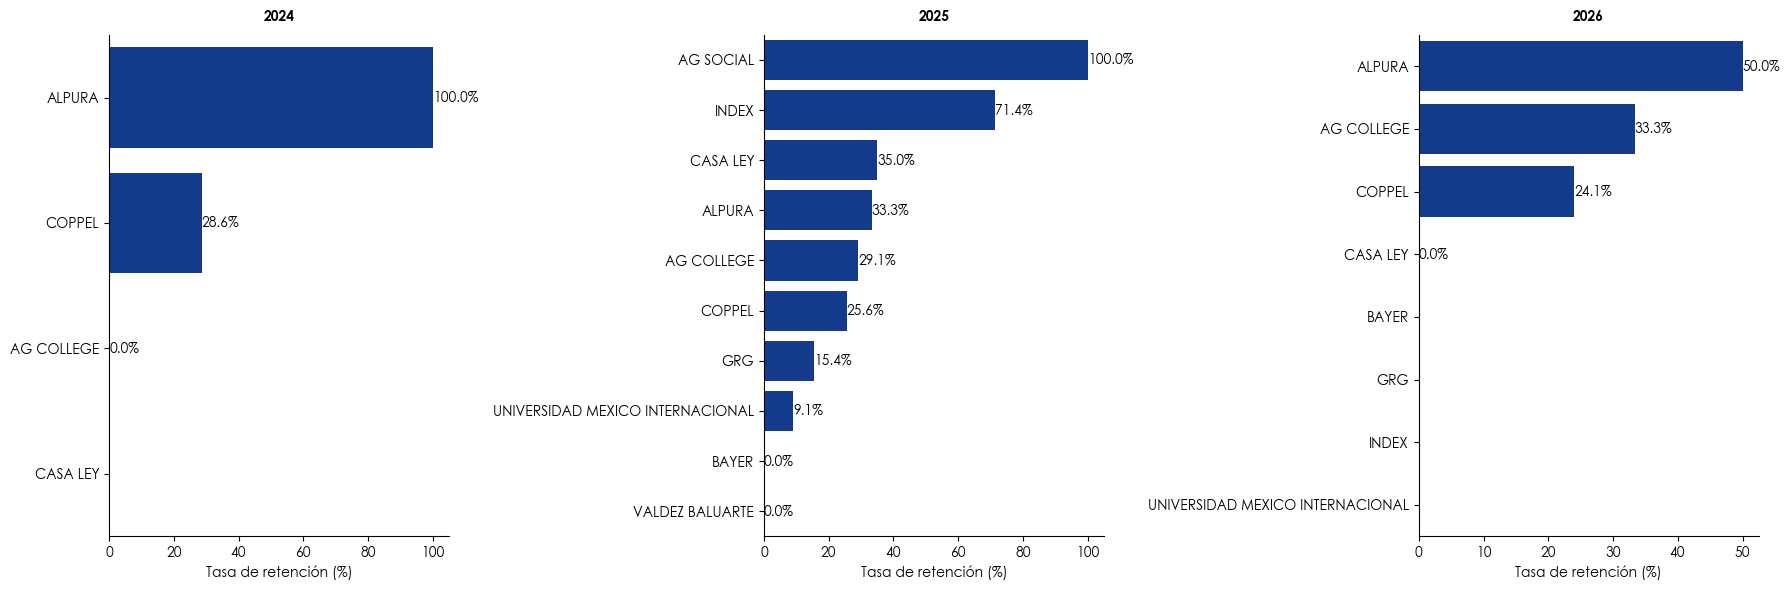

In [65]:
# Copia y ordena dentro de cada año
df_plot = retencion_corp.copy()


# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_retencion", y="corporacion", color="#0033A0")

# Títulos y estilo
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de retención (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [66]:
#Retención por programa
retencion_prog = (
    retencion
    .groupby(["anio", "programa"])
    .agg(
        total_intervenidos=("intervencion", "sum"),
        total_retencion=("retencion", lambda x: (x == "SI").sum())
    )
    .reset_index()
)
retencion_prog["tasa_retencion"] = (
    retencion_prog["total_retencion"] /
    retencion_prog["total_intervenidos"] * 100
).round(2)
retencion_prog


,anio,programa,total_intervenidos,total_retencion,tasa_retencion
0,2024,IDS Coppel,5,1,20.00
1,2024,LDG AG LIC,2,0,0.00
2,2024,LDG Ley,0,0,NaN
3,2024,LEG COPPEL,14,4,28.57
4,2024,MDN Coppel,4,1,25.00
5,2024,PREPA COPPEL,5,2,40.00
6,2024,Prepa alpura,1,1,100.00
7,2025,ADMISIONES IDS COPPEL,0,0,NaN
8,2025,BACHILLERATO FALCO ELECTRONICS,0,0,NaN
9,2025,BACHILLERATO INDEX,4,4,100.00


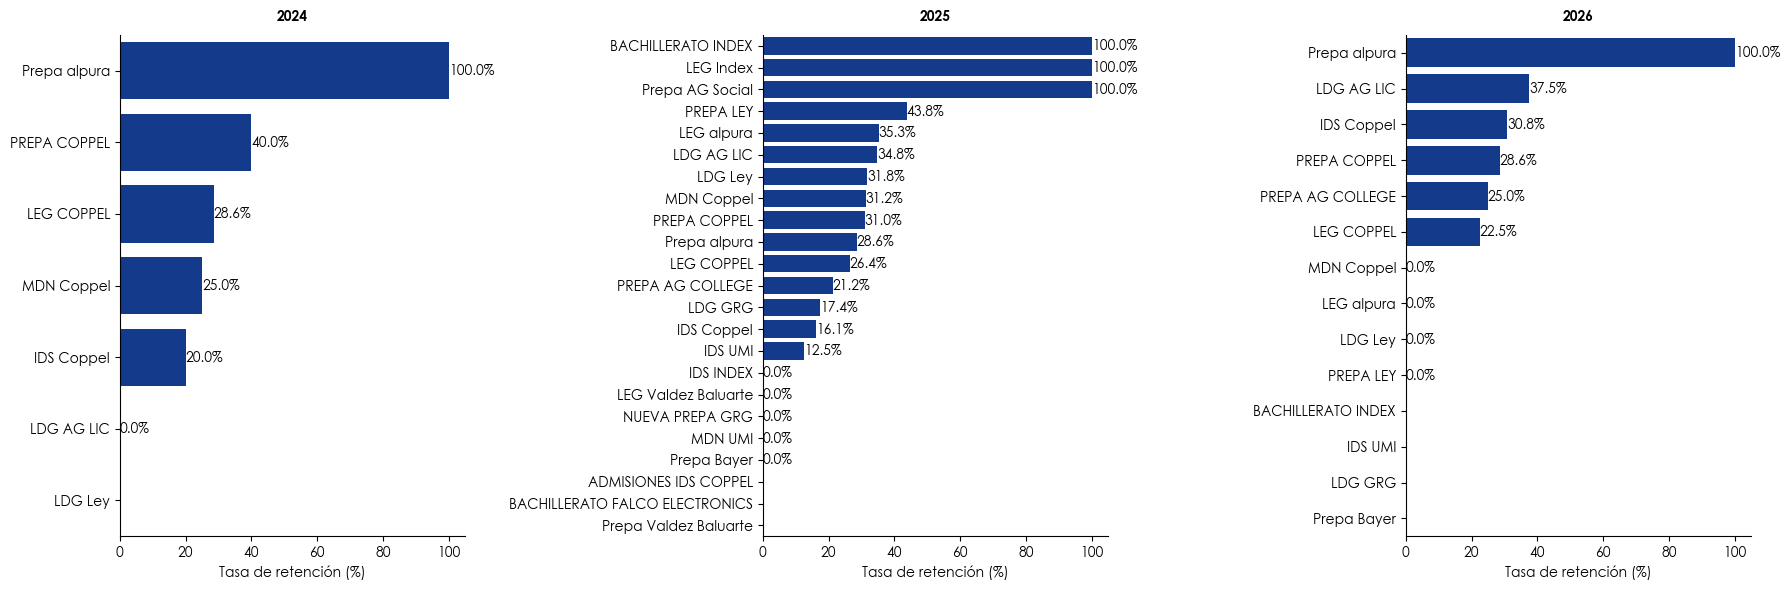

In [67]:
# Copia y ordena dentro de cada año
df_plot = retencion_prog.copy()


# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_retencion", y="programa", color="#0033A0")

# Títulos y estilo  
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de retención (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Abandono

In [68]:
##Calcular tasa de abandono por año
abandono_gral = (
    abandono
    .groupby("anio_referencia")
    .agg(
        total_registros=("id_alumno", "count"),
        total_bajas=("tuvo_baja_en_anio", "sum")
    )
    .reset_index()
)

# Calcular tasa de abandono
abandono_gral["tasa_abandono"] = (
    abandono_gral["total_bajas"] / abandono_gral["total_registros"]*100
)

abandono_gral

,anio_referencia,total_registros,total_bajas,tasa_abandono
0,2024,8577,1094,12.755043
1,2025,8035,1050,13.067828
2,2026,7703,232,3.011814


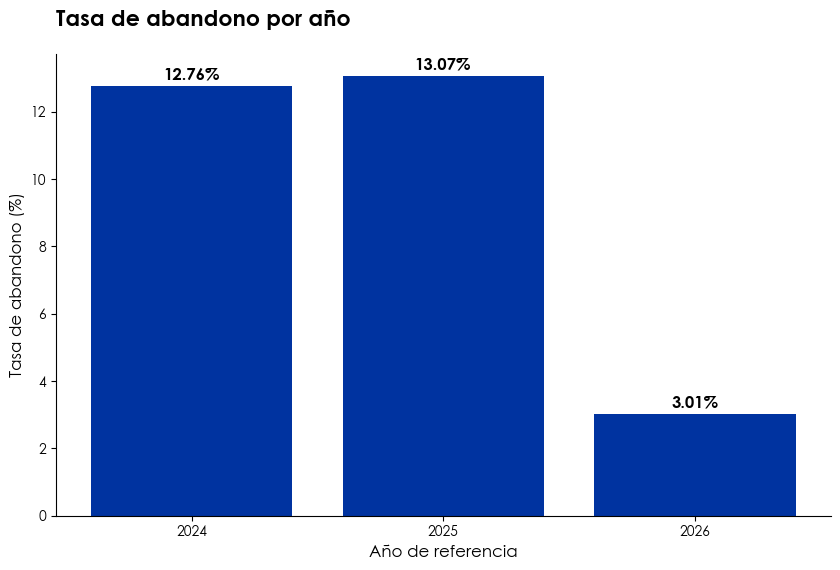

In [69]:
# Grafico de barras
plt.figure(figsize=(10, 6))
plt.bar(abandono_gral["anio_referencia"], abandono_gral["tasa_abandono"], color="#0033A0")
plt.title("Tasa de abandono por año", fontsize=16, pad=20, color="black", fontweight="bold", loc="left")
plt.xlabel("Año de referencia", fontsize=12)
plt.ylabel("Tasa de abandono (%)", fontsize=12)
#Añadir etiquetas de porcentaje encima de cada barra
for index, row in abandono_gral.iterrows():
    plt.text(row["anio_referencia"], row["tasa_abandono"] + 0.2,
              f"{row['tasa_abandono']:.2f}%", ha='center', fontsize=12, color="black", fontweight="bold")

plt.xticks(abandono_gral["anio_referencia"])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [70]:
# Abandono por corporación
abandono_corp = (
    abandono
    .groupby(["anio_referencia", "corporacion"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_bajas=("tuvo_baja_en_anio", "sum")
    )
    .reset_index()
)
abandono_corp["tasa_abandono"] = (
    abandono_corp["total_bajas"] / abandono_corp["total_registros"]*
    100
)
abandono_corp

,anio_referencia,corporacion,total_registros,total_bajas,tasa_abandono
0,2024,ACADEMIA GLOBAL POR MÉXICO,10,2,20.000000
1,2024,AG COLLEGE,1001,33,3.296703
2,2024,AG SOCIAL,107,0,0.000000
3,2024,ALPURA,135,18,13.333333
4,2024,CASA LEY,1873,206,10.998398
5,2024,COPPEL,5189,827,15.937560
6,2024,GRG,2,0,0.000000
7,2024,INDEX,82,0,0.000000
8,2024,MABE,18,0,0.000000
9,2024,OPERADORA SI,3,0,0.000000


In [71]:
abandono.head()

,anio_referencia,id_alumno,idmoodle,id_plan_estudio,programa,id_corporacion,corporacion,estado_inicial,tuvo_baja_en_anio,fecha_baja
0,2024,89385,701,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,1,1,2024-03-06 10:08:10
1,2024,89389,702,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,1,0,NaT
2,2024,89392,703,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,1,0,NaT
3,2024,89394,704,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,1,0,NaT
4,2024,89398,705,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,1,0,NaT


In [72]:
# Abandono por corporación
abandono_prog = (
    abandono
    .groupby(["anio_referencia", "programa"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_bajas=("tuvo_baja_en_anio", "sum")
    )
    .reset_index()
)
abandono_prog["tasa_abandono"] = (
    abandono_prog["total_bajas"] / abandono_prog["total_registros"]*
    100
)
abandono_prog

,anio_referencia,programa,total_registros,total_bajas,tasa_abandono
0,2024,ACADEMIA GLOBAL POR MEXICO,10,2,20.000000
1,2024,BACHILLERATO INDEX,13,0,0.000000
2,2024,CERTIFICACIONES EJECUTIVAS,69,0,0.000000
3,2024,ESCUELAS DE UCL,1576,170,10.786802
4,2024,IDS COPPEL,458,115,25.109170
...,...,...,...,...,...
72,2026,PREPA COPPEL,1348,74,5.489614
73,2026,PREPA LEY,171,7,4.093567
74,2026,PREPA OXXO,16,0,0.000000
75,2026,PREPA SUMATE,18,18,100.000000


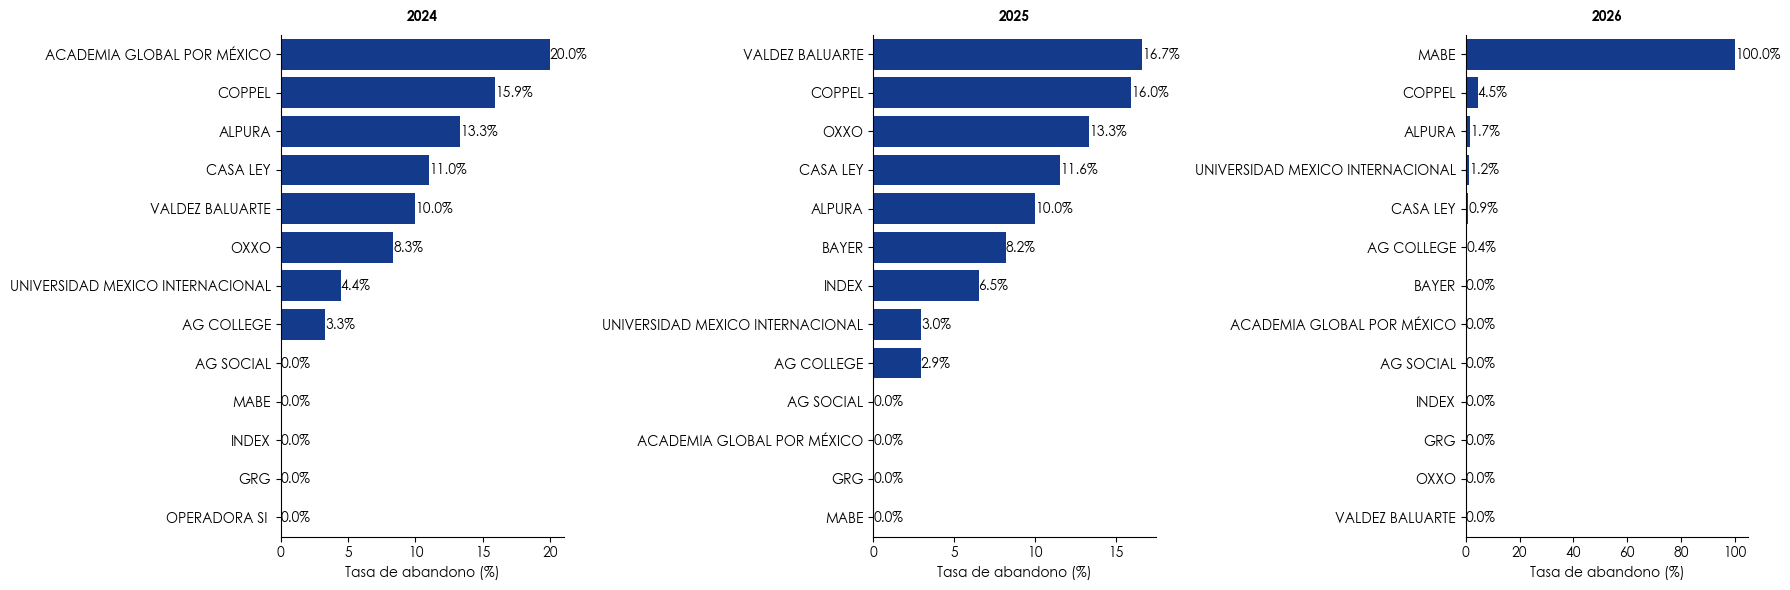

In [73]:
# Copia y ordena dentro de cada año
df_plot = abandono_corp.copy()


# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio_referencia",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_abandono", y="corporacion", color="#0033A0")

# Títulos y estilo
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de abandono (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

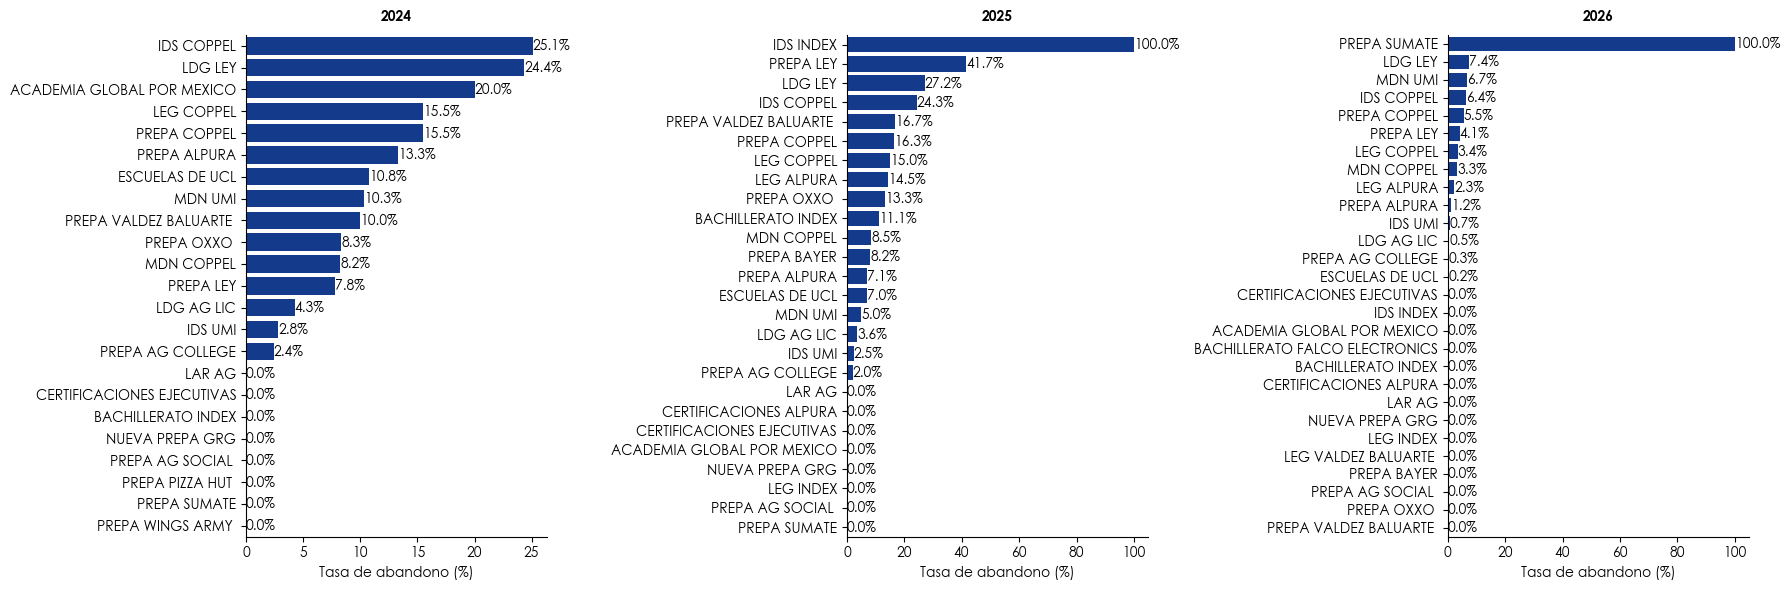

In [74]:
# Copia y ordena dentro de cada año
df_plot = abandono_prog.copy()
# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio_referencia",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_abandono", y="programa", color="#0033A0")

# Títulos y estilo
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de abandono (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Abandono por baja del programa

In [75]:
##Calcular tasa de abandono por año
abandono_gral_programa = (
    abandono_programa
    .groupby("anio_referencia")
    .agg(
        total_registros=("id_alumno", "count"),
        total_bajas=("tuvo_baja_en_anio", "sum")
    )
    .reset_index()
)

# Calcular tasa de abandono
abandono_gral_programa["tasa_abandono"] = (
    abandono_gral_programa["total_bajas"] / abandono_gral_programa["total_registros"]*100
)

abandono_gral_programa

,anio_referencia,total_registros,total_bajas,tasa_abandono
0,2024,8577,343,3.999067
1,2025,8035,323,4.019913
2,2026,7703,67,0.869791


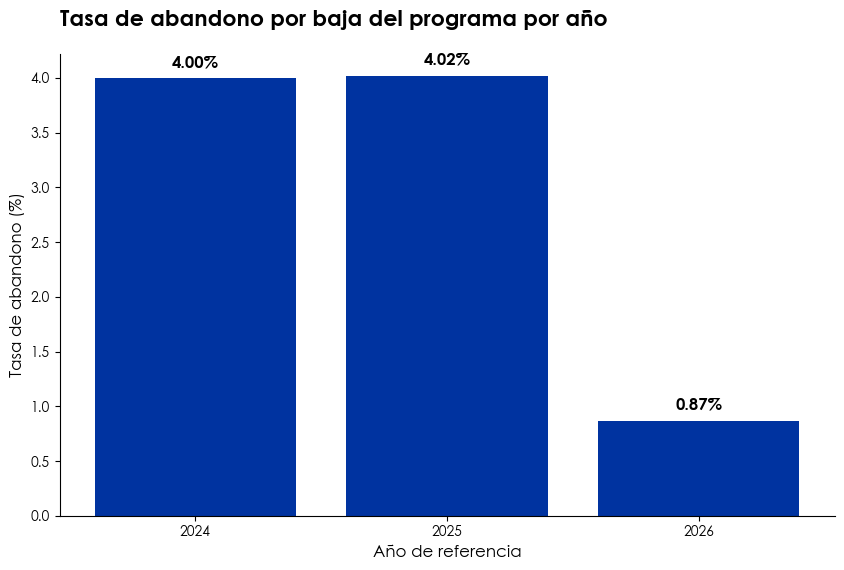

In [76]:
# Grafico de barras
plt.figure(figsize=(10, 6))
plt.bar(abandono_gral_programa["anio_referencia"], abandono_gral_programa["tasa_abandono"], color="#0033A0")
plt.title("Tasa de abandono por baja del programa por año", fontsize=16, pad=20, color="black", fontweight="bold", loc="left")
plt.xlabel("Año de referencia", fontsize=12)
plt.ylabel("Tasa de abandono (%)", fontsize=12)
#Añadir etiquetas de porcentaje encima de cada barra
for index, row in abandono_gral_programa.iterrows():
    plt.text(row["anio_referencia"], row["tasa_abandono"] + 0.1,
              f"{row['tasa_abandono']:.2f}%", ha='center', fontsize=12, color="black", fontweight="bold")

plt.xticks(abandono_gral_programa["anio_referencia"])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


#### Abandono por baja de la empresa


In [77]:
##Calcular tasa de abandono por año
abandono_gral_empresa = (
    abandono_empresa
    .groupby("anio_referencia")
    .agg(
        total_registros=("id_alumno", "count"),
        total_bajas=("tuvo_baja_en_anio", "sum")
    )
    .reset_index()
)

# Calcular tasa de abandono
abandono_gral_empresa["tasa_abandono"] = (
    abandono_gral_empresa["total_bajas"] / abandono_gral_empresa["total_registros"]*100
)

abandono_gral_empresa

,anio_referencia,total_registros,total_bajas,tasa_abandono
0,2024,8577,769,8.965839
1,2025,8035,735,9.147480
2,2026,7703,165,2.142023


### Abandono temprano

In [78]:
fragilidad

,id_alumno,id_moodle,id_plan_estudio,programa,id_nivel_estudio,nivel,id_corporacion,corporacion,anio_inscripcion,fecha_inscripcion,periodo_inscripcion,primer_carga,fecha_baja,fecha_solicitud_baja,periodo,id_moodle_ultima_carga,ultima_materia
0,91434,2389,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-05-15 12:51:38,2024-06-01,None,None,None,NaN,NaN,None
1,109163,3638,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-09-04 11:16:39,2024-09-01,None,2026-01-19,None,NaN,NaN,None
2,199275,56732,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:37:40,2025-10-01,2025-10-10 14:16:03,None,None,2.0,24.0,Matemáticas II
3,199276,56733,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:39:35,2025-10-01,2025-10-10 14:16:58,None,None,2.0,24.0,Matemáticas II
4,199277,56734,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:42:09,2025-10-01,2025-10-10 14:17:38,None,None,2.0,24.0,Matemáticas II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7546,194956,55515,123,LEG VALDEZ BALUARTE,4,LICENCIATURA,19,VALDEZ BALUARTE,2025,2025-05-30 13:37:57,2025-06-01,2025-06-04 10:19:47,2025-09-02,2025-06-24,NaN,307.0,Introducción a los Modelos Ágiles de Administr...
7547,197140,56098,123,LEG VALDEZ BALUARTE,4,LICENCIATURA,19,VALDEZ BALUARTE,2025,2025-07-23 15:32:50,2025-08-01,2025-08-04 15:21:54,None,None,2.0,477.0,Digitalización en los Negocios I. (Tecnologías...
7548,197763,56300,123,LEG VALDEZ BALUARTE,4,LICENCIATURA,19,VALDEZ BALUARTE,2025,2025-08-04 10:57:23,2025-08-01,2025-08-05 19:18:25,None,None,2.0,475.0,Estrategia Corporativa. (Organización y Desarr...
7549,198810,56544,123,LEG VALDEZ BALUARTE,4,LICENCIATURA,19,VALDEZ BALUARTE,2025,2025-08-28 10:05:27,2025-09-01,2025-09-03 14:40:10,None,None,3.0,480.0,Derecho Laboral


In [79]:
##Abandono general

# Asegurar que las fechas sean datetime
fragilidad["fecha_inscripcion"] = pd.to_datetime(fragilidad["fecha_inscripcion"])
fragilidad["fecha_baja"] = pd.to_datetime(fragilidad["fecha_baja"])

# Diferencia en días
fragilidad["dias_a_baja"] = (
    fragilidad["fecha_baja"] - fragilidad["fecha_inscripcion"]
).dt.days

# Variable abandono semana 4
fragilidad["abandono_sem4"] = np.where(
    (fragilidad["dias_a_baja"].notna()) & (fragilidad["dias_a_baja"] <= 28),
    1,
    0
)
fragilidad.head()

,id_alumno,id_moodle,id_plan_estudio,programa,id_nivel_estudio,nivel,id_corporacion,corporacion,anio_inscripcion,fecha_inscripcion,periodo_inscripcion,primer_carga,fecha_baja,fecha_solicitud_baja,periodo,id_moodle_ultima_carga,ultima_materia,dias_a_baja,abandono_sem4
0,91434,2389,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-05-15 12:51:38,2024-06-01,None,NaT,None,NaN,NaN,None,NaN,0
1,109163,3638,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-09-04 11:16:39,2024-09-01,None,2026-01-19,None,NaN,NaN,None,501.0,0
2,199275,56732,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:37:40,2025-10-01,2025-10-10 14:16:03,NaT,None,2.0,24.0,Matemáticas II,NaN,0
3,199276,56733,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:39:35,2025-10-01,2025-10-10 14:16:58,NaT,None,2.0,24.0,Matemáticas II,NaN,0
4,199277,56734,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:42:09,2025-10-01,2025-10-10 14:17:38,NaT,None,2.0,24.0,Matemáticas II,NaN,0


In [80]:
abandono_4_sem = (
    fragilidad
    .groupby("anio_inscripcion")
    .agg(
        total_registros=("id_alumno", "count"),
        total_abandono_sem4=("abandono_sem4", "sum")
    )
    .reset_index()
)   
# Calcular tasa de abandono
abandono_4_sem["tasa_abandono_sem4"] = (
    abandono_4_sem["total_abandono_sem4"] / abandono_4_sem["total_registros"]*100
).round(2)
abandono_4_sem


,anio_inscripcion,total_registros,total_abandono_sem4,tasa_abandono_sem4
0,2024,4019,48,1.19
1,2025,2935,49,1.67
2,2026,597,7,1.17


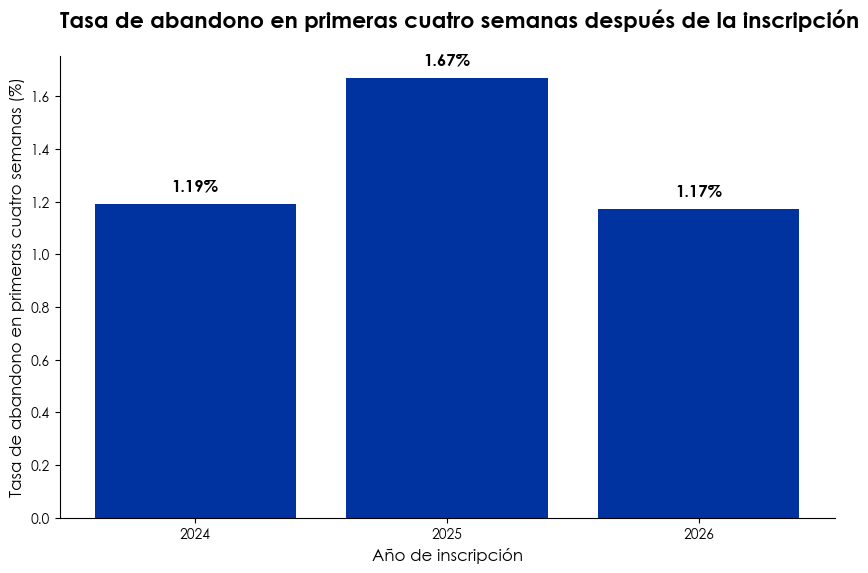

In [81]:
# GArfico de barras
plt.figure(figsize=(10, 6))
plt.bar(abandono_4_sem["anio_inscripcion"], abandono_4_sem["tasa_abandono_sem4"], color="#0033A0")
plt.title("Tasa de abandono en primeras cuatro semanas después de la inscripción", fontsize=16, pad=20, color="black", fontweight="bold", loc="left")
plt.xlabel("Año de inscripción", fontsize=12)
plt.ylabel("Tasa de abandono en primeras cuatro semanas (%)", fontsize=12)
#Añadir etiquetas de porcentaje encima de cada barra
for index, row in abandono_4_sem.iterrows():
    plt.text(row["anio_inscripcion"], row["tasa_abandono_sem4"] + 0.05,
              f"{row['tasa_abandono_sem4']:.2f}%", ha='center', fontsize=12, color="black", fontweight="bold")
plt.xticks(abandono_4_sem["anio_inscripcion"])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [82]:
## Abandono temprano por corporación

abandono_corp_4_sem = (
    fragilidad
    .groupby(["anio_inscripcion", "corporacion"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_abandono_sem4=("abandono_sem4", "sum")
    )
    .reset_index()
)
abandono_corp_4_sem["tasa_abandono_sem4"] = (
    abandono_corp_4_sem["total_abandono_sem4"] / abandono_corp_4_sem["total_registros"]*
    100
).round(2)

abandono_corp_4_sem

,anio_inscripcion,corporacion,total_registros,total_abandono_sem4,tasa_abandono_sem4
0,2024,ACADEMIA GLOBAL POR MÉXICO,2,0,0.00
1,2024,AG COLLEGE,329,0,0.00
2,2024,ALPURA,279,2,0.72
3,2024,BAYER,87,0,0.00
4,2024,CASA LEY,251,1,0.40
5,2024,COPPEL,2983,44,1.48
6,2024,INDEX,22,1,4.55
7,2024,OXXO,12,0,0.00
8,2024,UNIVERSIDAD MEXICO INTERNACIONAL,52,0,0.00
9,2024,VALDEZ BALUARTE,2,0,0.00


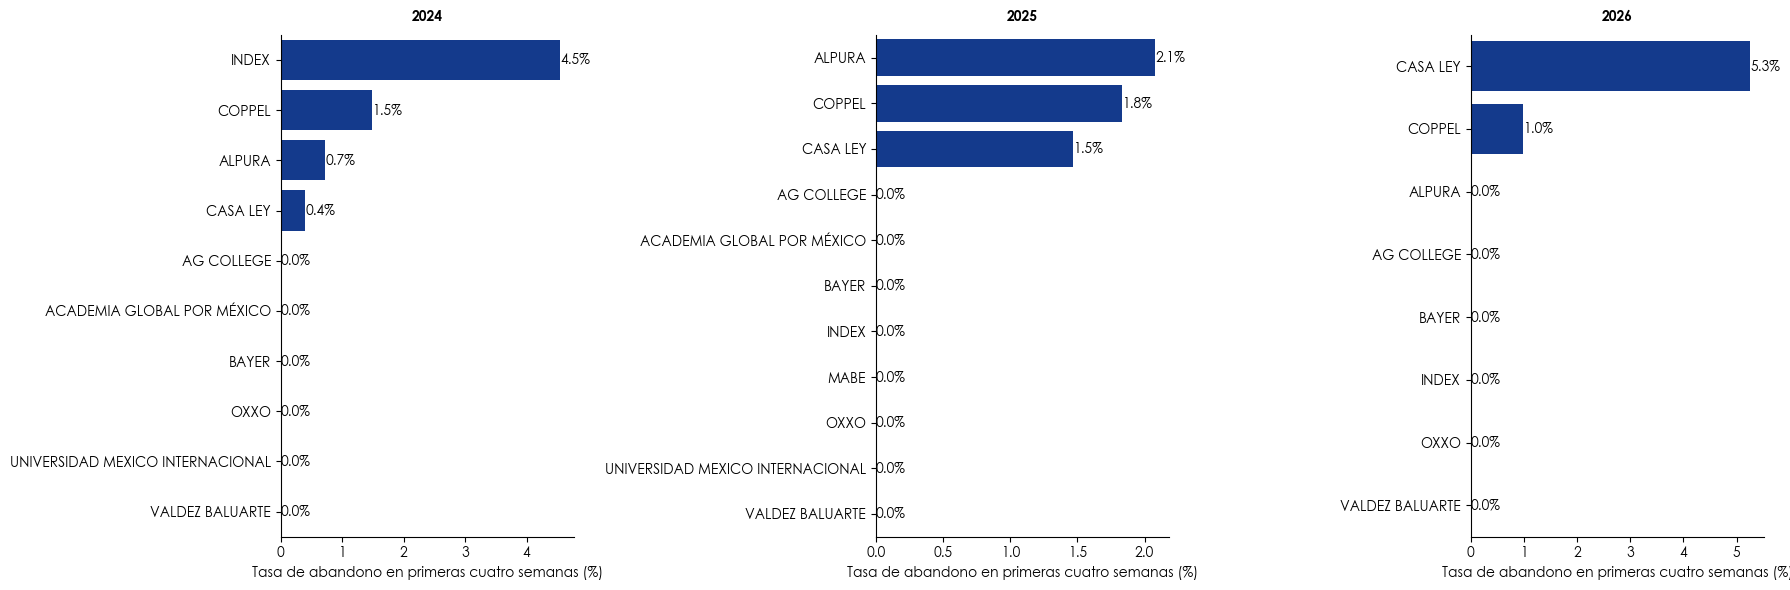

In [83]:
# Grafico de barras
# Copia y ordena dentro de cada año
df_plot = abandono_corp_4_sem.copy()


# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio_inscripcion",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_abandono_sem4", y="corporacion", color="#0033A0")

# Títulos y estilo  
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de abandono en primeras cuatro semanas (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
#plt.show()

In [111]:
#Periodo nulo se refiere a que no terminaron ninguna materia. Pudieron haber cargado alguna pero ninguna tiene calificación
bajas_periodo = (
    fragilidad_programa[fragilidad_programa["fecha_baja"].notna()]
    .groupby(["anio_inscripcion", "periodo", "nivel"], dropna=False)
    .size()
    .reset_index(name="bajas")
)
#Sustituir NaN por "Sin periodo"
bajas_periodo["periodo"] = bajas_periodo["periodo"].fillna(0)
bajas_periodo["periodo"] = bajas_periodo["periodo"].astype(int)   

bajas_periodo

,anio_inscripcion,periodo,nivel,bajas
0,2024,1,INGENIERIA,66
1,2024,1,LICENCIATURA,69
2,2024,1,MAESTRIA,9
3,2024,1,PREPARATORIA,42
4,2024,2,INGENIERIA,15
5,2024,2,LICENCIATURA,25
6,2024,2,MAESTRIA,3
7,2024,2,PREPARATORIA,13
8,2024,3,INGENIERIA,6
9,2024,3,LICENCIATURA,11


In [141]:
# Total de bajas por nivel
total_nivel = (
    bajas_periodo
    .groupby("nivel")["bajas"]
    .sum()
    .reset_index(name="total_bajas")
)

print("Total de bajas por año de inscripción:")
print(total_nivel.groupby("nivel")["total_bajas"].sum())

# Bajas en periodos 0 y 1
bajas_01 = (
    bajas_periodo[bajas_periodo["periodo"].isin([0,1])]
    .groupby("nivel")["bajas"]
    .sum()
    .reset_index(name="bajas_p0_p1")
)

# Unir y calcular porcentaje
resumen = (
    total_nivel
    .merge(bajas_01, on="nivel", how="left")
)

resumen["porcentaje_p0_p1"] = (
    resumen["bajas_p0_p1"] / resumen["total_bajas"] * 100
)

resumen["porcentaje_p0_p1"] = resumen["porcentaje_p0_p1"].round(1)
resumen

Total de bajas por año de inscripción:
nivel
INGENIERIA      166
LICENCIATURA    402
MAESTRIA         31
PREPARATORIA    195
Name: total_bajas, dtype: int64


,nivel,total_bajas,bajas_p0_p1,porcentaje_p0_p1
0,INGENIERIA,166,136,81.9
1,LICENCIATURA,402,335,83.3
2,MAESTRIA,31,26,83.9
3,PREPARATORIA,195,150,76.9


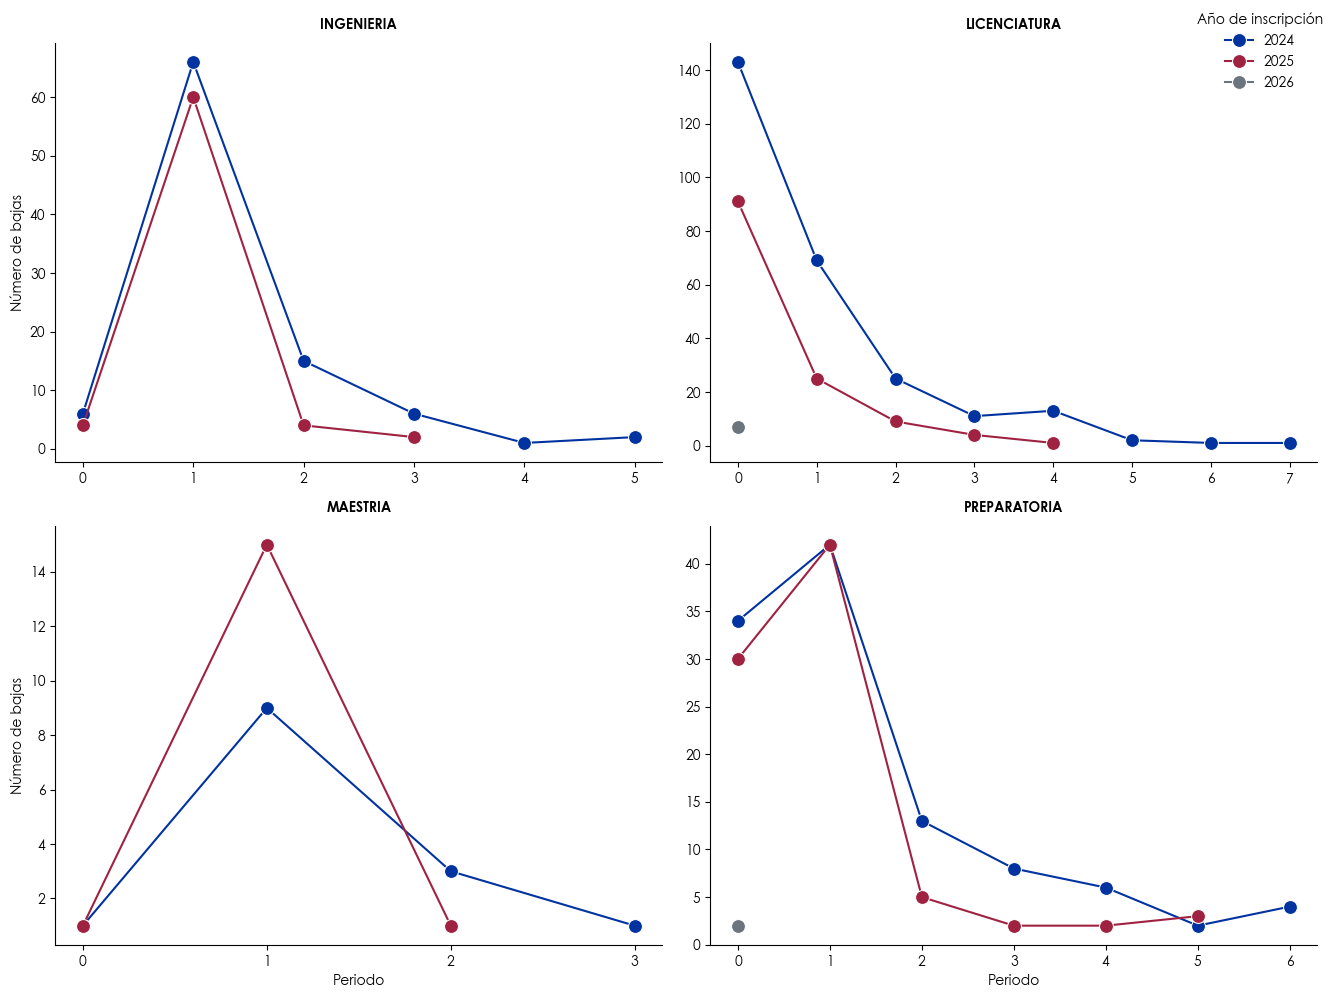

In [121]:
# Asegurar que periodo sea entero
bajas_periodo["periodo"] = bajas_periodo["periodo"].astype(int)

# Crear facets por nivel educativo (2 filas)
g = sns.FacetGrid(
    bajas_periodo,
    col="nivel",
    col_wrap=2,
    sharex=False,
    sharey=False,
    height=5,
    aspect=1.2
)

# Gráfico de líneas
g.map_dataframe(
    sns.lineplot,
    x="periodo",
    y="bajas",
    hue="anio_inscripcion",
    marker="o",
    markersize=10,
    palette=["#0033A0", "#9F2241", "#6C757D"]
)

# Leyenda
g.add_legend(title="Año de inscripción", fontsize=10, title_fontsize=12, loc="upper right")

# Títulos
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)

# Etiquetas
g.set_axis_labels("Periodo", "Número de bajas")

# Estilo
for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
        # obtener el nivel del facet
    titulo = ax.get_title().split(" = ")[-1]
    
    # datos de ese nivel
    data_nivel = bajas_periodo[bajas_periodo["nivel"] == titulo]
    
    # ticks enteros según los periodos disponibles
    ticks = sorted(data_nivel["periodo"].unique())
    
    ax.set_xticks(ticks)
    

plt.tight_layout()
plt.show()

In [85]:
fragilidad

,id_alumno,id_moodle,id_plan_estudio,programa,id_nivel_estudio,nivel,id_corporacion,corporacion,anio_inscripcion,fecha_inscripcion,periodo_inscripcion,primer_carga,fecha_baja,fecha_solicitud_baja,periodo,id_moodle_ultima_carga,ultima_materia,dias_a_baja,abandono_sem4
0,91434,2389,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-05-15 12:51:38,2024-06-01,None,NaT,None,NaN,NaN,None,NaN,0
1,109163,3638,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-09-04 11:16:39,2024-09-01,None,2026-01-19,None,NaN,NaN,None,501.0,0
2,199275,56732,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:37:40,2025-10-01,2025-10-10 14:16:03,NaT,None,2.0,24.0,Matemáticas II,NaN,0
3,199276,56733,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:39:35,2025-10-01,2025-10-10 14:16:58,NaT,None,2.0,24.0,Matemáticas II,NaN,0
4,199277,56734,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:42:09,2025-10-01,2025-10-10 14:17:38,NaT,None,2.0,24.0,Matemáticas II,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7546,194956,55515,123,LEG VALDEZ BALUARTE,4,LICENCIATURA,19,VALDEZ BALUARTE,2025,2025-05-30 13:37:57,2025-06-01,2025-06-04 10:19:47,2025-09-02,2025-06-24,NaN,307.0,Introducción a los Modelos Ágiles de Administr...,94.0,0
7547,197140,56098,123,LEG VALDEZ BALUARTE,4,LICENCIATURA,19,VALDEZ BALUARTE,2025,2025-07-23 15:32:50,2025-08-01,2025-08-04 15:21:54,NaT,None,2.0,477.0,Digitalización en los Negocios I. (Tecnologías...,NaN,0
7548,197763,56300,123,LEG VALDEZ BALUARTE,4,LICENCIATURA,19,VALDEZ BALUARTE,2025,2025-08-04 10:57:23,2025-08-01,2025-08-05 19:18:25,NaT,None,2.0,475.0,Estrategia Corporativa. (Organización y Desarr...,NaN,0
7549,198810,56544,123,LEG VALDEZ BALUARTE,4,LICENCIATURA,19,VALDEZ BALUARTE,2025,2025-08-28 10:05:27,2025-09-01,2025-09-03 14:40:10,NaT,None,3.0,480.0,Derecho Laboral,NaN,0


In [149]:
bajas_materia = (
    fragilidad_programa[fragilidad_programa["fecha_baja"].notna()]
    .groupby(["periodo","anio_inscripcion","nivel", "ultima_materia"], dropna=False)
    .size()
    .reset_index(name="bajas")
).sort_values(["anio_inscripcion", "bajas"], ascending=[True, False])
bajas_materia

,periodo,anio_inscripcion,nivel,ultima_materia,bajas
139,NaN,2024,LICENCIATURA,Teoría del Conocimiento,90
4,1.0,2024,INGENIERIA,Sistemas Operativos I,25
137,NaN,2024,LICENCIATURA,Introducción a los Modelos Ágiles de Administr...,23
10,1.0,2024,LICENCIATURA,Psicología Organizacional,19
0,1.0,2024,INGENIERIA,Diseño de Interfaces I,18
...,...,...,...,...,...
156,NaN,2026,LICENCIATURA,Teoría del Conocimiento,3
157,NaN,2026,LICENCIATURA,NaN,3
155,NaN,2026,LICENCIATURA,Introducción a los Modelos Ágiles de Administr...,1
158,NaN,2026,PREPARATORIA,Taller de Lectura y Redacción I,1


In [147]:
bajas_materia = (
    fragilidad_programa[fragilidad_programa["fecha_baja"].notna()]
    .groupby(["periodo","anio_inscripcion","nivel", "ultima_materia"], dropna=False)
    .size()
    .reset_index(name="bajas")
).sort_values(["anio_inscripcion", "bajas"], ascending=[True, False])

print("Total de bajas por año de inscripción:")
print(bajas_materia.groupby("anio_inscripcion")["bajas"].sum())
print("Total de bajas")
print(bajas_materia["bajas"].sum())

#Top 3 de materias con más bajas por nivel
top_materias = (
    bajas_materia
    .groupby(["nivel", "ultima_materia"])
    .agg(total_bajas=("bajas", "sum"))
    .reset_index()
)

# Total de bajas por nivel
top_materias["total_nivel"] = top_materias.groupby("nivel")["total_bajas"].transform("sum")

# Porcentaje respecto al total del nivel
top_materias["porcentaje_nivel"] = (
    top_materias["total_bajas"] / top_materias["total_nivel"] * 100
)

# Ranking
top_materias["rank"] = top_materias.groupby("nivel")["total_bajas"].rank(
    method="first", ascending=False
)

# Top 3
top_materias = top_materias[top_materias["rank"] <= 3]\
    .sort_values(["nivel", "total_bajas"], ascending=[True, False])

top_materias["porcentaje_nivel"] = top_materias["porcentaje_nivel"].round(1)

top_materias


Total de bajas por año de inscripción:
anio_inscripcion
2024    484
2025    301
2026      9
Name: bajas, dtype: int64
Total de bajas
794


,nivel,ultima_materia,total_bajas,total_nivel,porcentaje_nivel,rank
15,INGENIERIA,Sistemas Operativos I,41,156,26.3,1.0
1,INGENIERIA,Diseño de Interfaces I,28,156,17.9,2.0
7,INGENIERIA,Introducción al Desarrollo de Software,25,156,16.0,3.0
44,LICENCIATURA,Teoría del Conocimiento,160,369,43.4,1.0
38,LICENCIATURA,Introducción a los Modelos Ágiles de Administr...,47,369,12.7,2.0
42,LICENCIATURA,Psicología Organizacional,35,369,9.5,3.0
50,MAESTRIA,Gestión de Operaciones y Servicios en los Nego...,14,29,48.3,1.0
49,MAESTRIA,Gestión de Liderazgo Directivo,5,29,17.2,2.0
48,MAESTRIA,Estrategias Digitales de Mercadotecnia,3,29,10.3,3.0
78,PREPARATORIA,Taller de Lectura y Redacción I,51,172,29.7,1.0


In [ ]:
# Total de bajas
total_bajas = bajas_materia["bajas"].sum()

# Bajas con periodo NaN y materia NaN
bajas_nan_nan = (
    bajas_materia[
        bajas_materia["periodo"].isna() &
        bajas_materia["ultima_materia"].isna()
    ]["bajas"].sum()
)

# Porcentaje
porcentaje = bajas_nan_nan / total_bajas * 100

bajas_nan_nan, porcentaje

In [ ]:
resumen_nan = (
    bajas_materia
    .assign(
        caso_nan=lambda x: x["periodo"].isna() & x["ultima_materia"].isna()
    )
    .groupby("anio_inscripcion")
    .agg(
        total_bajas=("bajas", "sum"),
        bajas_nan_nan=("bajas", lambda x: x[bajas_materia.loc[x.index, "periodo"].isna() &
                                            bajas_materia.loc[x.index, "ultima_materia"].isna()].sum())
    )
)

resumen_nan["porcentaje_nan_nan"] = (
    resumen_nan["bajas_nan_nan"] / resumen_nan["total_bajas"] * 100
)

resumen_nan

,total_bajas,bajas_nan_nan,porcentaje_nan_nan
anio_inscripcion,,,
2024,484,35,7.231405
2025,301,29,9.634551
2026,9,4,44.444444


2026-03-12 17:49:27,320| ERROR   | Socket exception: Se ha forzado la interrupción de una conexión existente por el host remoto (10054)
2026-03-12 17:49:29,358| ERROR   | Socket exception: Se ha forzado la interrupción de una conexión existente por el host remoto (10054)


In [87]:
bajas_periodo = (
    fragilidad_programa[fragilidad_programa["fecha_baja"].notna()]
    .groupby(["anio_inscripcion", "periodo"], dropna=False)
    .size()
    .reset_index(name="bajas")
)

bajas_periodo

,anio_inscripcion,periodo,bajas
0,2024,1.0,186
1,2024,2.0,56
2,2024,3.0,26
3,2024,4.0,20
4,2024,5.0,6
5,2024,6.0,5
6,2024,7.0,1
7,2024,NaN,184
8,2025,1.0,142
9,2025,2.0,19


In [88]:
# Abandono temprano por programa

abandono_prog_4_sem = (
    fragilidad
    .groupby(["anio_inscripcion", "programa"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_abandono_sem4=("abandono_sem4", "sum")
    )
    .reset_index()
)
abandono_prog_4_sem["tasa_abandono_sem4"] = (
    abandono_prog_4_sem["total_abandono_sem4"] / abandono_prog_4_sem["total_registros"]*
    100
).round(2)
abandono_prog_4_sem

,anio_inscripcion,programa,total_registros,total_abandono_sem4,tasa_abandono_sem4
0,2024,ACADEMIA GLOBAL POR MEXICO,2,0,0.00
1,2024,BACHILLERATO INDEX,13,1,7.69
2,2024,IDS COPPEL,334,6,1.80
3,2024,IDS INDEX,6,0,0.00
4,2024,IDS UMI,45,0,0.00
5,2024,INGENIERÍA INDUSTRIAL AG COLLEGE,1,0,0.00
6,2024,LDG AG LIC,142,0,0.00
7,2024,LDG LEY,110,1,0.91
8,2024,LEG ALPURA,186,2,1.08
9,2024,LEG COPPEL,1335,18,1.35


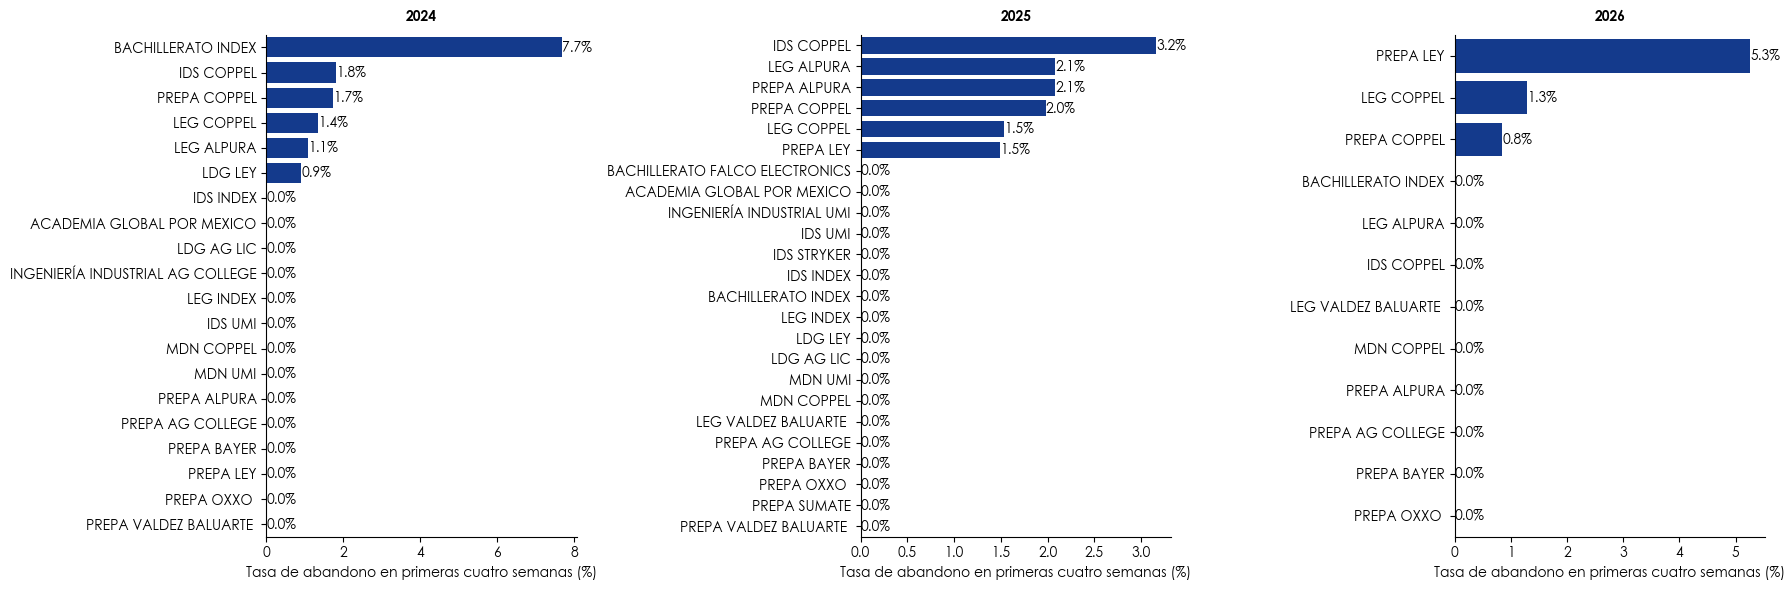

In [89]:
# Grafico de barras
# Copia y ordena dentro de cada año
df_plot = abandono_prog_4_sem.copy()


# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio_inscripcion",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_abandono_sem4", y="programa", color="#0033A0")

# Títulos y estilo  
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de abandono en primeras cuatro semanas (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [90]:
fragilidad_programa

,id_alumno,id_moodle,id_plan_estudio,programa,id_nivel_estudio,nivel,id_corporacion,corporacion,anio_inscripcion,fecha_inscripcion,periodo_inscripcion,primer_carga,fecha_baja,fecha_solicitud_baja,periodo,id_moodle_ultima_carga,ultima_materia
0,91434,2389,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-05-15 12:51:38,2024-06-01,None,None,None,NaN,NaN,None
1,109163,3638,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-09-04 11:16:39,2024-09-01,None,2026-01-19,None,NaN,NaN,None
2,199275,56732,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:37:40,2025-10-01,2025-10-10 14:16:03,None,None,2.0,24.0,Matemáticas II
3,199276,56733,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:39:35,2025-10-01,2025-10-10 14:16:58,None,None,2.0,24.0,Matemáticas II
4,199277,56734,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:42:09,2025-10-01,2025-10-10 14:17:38,None,None,2.0,24.0,Matemáticas II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7546,194956,55515,123,LEG VALDEZ BALUARTE,4,LICENCIATURA,19,VALDEZ BALUARTE,2025,2025-05-30 13:37:57,2025-06-01,2025-06-04 10:19:47,2025-09-02,2025-06-24,NaN,307.0,Introducción a los Modelos Ágiles de Administr...
7547,197140,56098,123,LEG VALDEZ BALUARTE,4,LICENCIATURA,19,VALDEZ BALUARTE,2025,2025-07-23 15:32:50,2025-08-01,2025-08-04 15:21:54,None,None,2.0,477.0,Digitalización en los Negocios I. (Tecnologías...
7548,197763,56300,123,LEG VALDEZ BALUARTE,4,LICENCIATURA,19,VALDEZ BALUARTE,2025,2025-08-04 10:57:23,2025-08-01,2025-08-05 19:18:25,None,None,2.0,475.0,Estrategia Corporativa. (Organización y Desarr...
7549,198810,56544,123,LEG VALDEZ BALUARTE,4,LICENCIATURA,19,VALDEZ BALUARTE,2025,2025-08-28 10:05:27,2025-09-01,2025-09-03 14:40:10,None,None,3.0,480.0,Derecho Laboral


In [91]:
##Abandono general por baja del programa

# Asegurar que las fechas sean datetime
fragilidad_programa["fecha_inscripcion"] = pd.to_datetime(fragilidad_programa["fecha_inscripcion"])
fragilidad_programa["fecha_baja"] = pd.to_datetime(fragilidad_programa["fecha_baja"])

# Diferencia en días
fragilidad_programa["dias_a_baja"] = (
    fragilidad_programa["fecha_baja"] - fragilidad_programa["fecha_inscripcion"]
).dt.days

# Variable abandono semana 4
fragilidad_programa["abandono_sem4"] = np.where(
    (fragilidad_programa["dias_a_baja"].notna()) & (fragilidad_programa["dias_a_baja"] <= 28),
    1,
    0
)
fragilidad_programa.head()

,id_alumno,id_moodle,id_plan_estudio,programa,id_nivel_estudio,nivel,id_corporacion,corporacion,anio_inscripcion,fecha_inscripcion,periodo_inscripcion,primer_carga,fecha_baja,fecha_solicitud_baja,periodo,id_moodle_ultima_carga,ultima_materia,dias_a_baja,abandono_sem4
0,91434,2389,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-05-15 12:51:38,2024-06-01,None,NaT,None,NaN,NaN,None,NaN,0
1,109163,3638,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-09-04 11:16:39,2024-09-01,None,2026-01-19,None,NaN,NaN,None,501.0,0
2,199275,56732,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:37:40,2025-10-01,2025-10-10 14:16:03,NaT,None,2.0,24.0,Matemáticas II,NaN,0
3,199276,56733,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:39:35,2025-10-01,2025-10-10 14:16:58,NaT,None,2.0,24.0,Matemáticas II,NaN,0
4,199277,56734,84,ACADEMIA GLOBAL POR MEXICO,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:42:09,2025-10-01,2025-10-10 14:17:38,NaT,None,2.0,24.0,Matemáticas II,NaN,0


In [92]:
abandono_4_sem_programa = (
    fragilidad_programa
    .groupby("anio_inscripcion")
    .agg(
        total_registros=("id_alumno", "count"),
        total_abandono_sem4=("abandono_sem4", "sum")
    )
    .reset_index()
)   
# Calcular tasa de abandono
abandono_4_sem_programa["tasa_abandono_sem4"] = (
    abandono_4_sem_programa["total_abandono_sem4"] / abandono_4_sem_programa["total_registros"]*100
).round(2)
abandono_4_sem_programa


,anio_inscripcion,total_registros,total_abandono_sem4,tasa_abandono_sem4
0,2024,4019,31,0.77
1,2025,2935,31,1.06
2,2026,597,3,0.50


In [93]:
abandono_4_sem_periodo_prog = (
        fragilidad_programa

    .groupby(["anio_inscripcion","periodo"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_abandono_sem4=("abandono_sem4", "sum")
    )
    .reset_index()
)   
# Calcular tasa de abandono
abandono_4_sem_periodo_prog["tasa_abandono_sem4"] = (
    abandono_4_sem_periodo_prog["total_abandono_sem4"] / abandono_4_sem_periodo_prog["total_registros"]*100
).round(2)
abandono_4_sem_periodo_prog

,anio_inscripcion,periodo,total_registros,total_abandono_sem4,tasa_abandono_sem4
0,2024,1.0,922,3,0.33
1,2024,2.0,483,1,0.21
2,2024,3.0,315,1,0.32
3,2024,4.0,325,2,0.62
4,2024,5.0,202,2,0.99
5,2024,6.0,620,2,0.32
6,2024,7.0,96,1,1.04
7,2024,8.0,69,0,0.00
8,2024,9.0,48,0,0.00
9,2024,10.0,83,0,0.00
